# Graph Learning Intuition

Main ideas:
- node features are updated from local neighborhoods
- one message-passing step mixes information from adjacent nodes
- stacked message-passing steps widen the receptive field
- graph-level pooling turns node states into a molecule representation

In [103]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

In [104]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))
bbbp = pd.read_csv(DATA_DIR / "BBBP.csv")
print("BBBP shape:", bbbp.shape)

BBBP shape: (2050, 4)


## 2. Neighborhood Aggregation on a BBBP Similarity Graph

The same idea works on a molecule-similarity graph: each molecule node can borrow signal from its nearest neighbors.

In [110]:
sample = bbbp[["name", "smiles", "p_np"]].head(20).copy()
vectorizer = CountVectorizer(analyzer="char", ngram_range=(2, 4), min_df=1)
feature_matrix = vectorizer.fit_transform(sample["smiles"])
similarity = cosine_similarity(feature_matrix)
similarity_graph = (similarity >= 0.45).astype(float)
np.fill_diagonal(similarity_graph, 0.0)
node_signal = sample[["p_np"]].to_numpy(dtype=float)
similarity_degree = similarity_graph.sum(axis=1, keepdims=True)
normalized_similarity = similarity_graph / np.clip(
    similarity_degree, a_min=1.0, a_max=None
)
neighbor_signal = normalized_similarity @ node_signal
comparison_df = pd.DataFrame(
    {
        "molecule": sample["name"].fillna(sample.index.to_series().astype(str)),
        "original_label": node_signal.ravel(),
        "neighbor_average": neighbor_signal.ravel(),
        "degree": similarity_graph.sum(axis=1).astype(int),
    }
)
display(comparison_df.head(10))

,molecule,original_label,neighbor_average,degree
0,Propanolol,1.0,0.923077,13
1,Terbutylchlorambucil,1.0,0.928571,14
2,40730,1.0,0.857143,7
3,24,1.0,1.000000,10
4,cloxacillin,1.0,0.923077,13
5,cefoperazone,1.0,1.000000,9
6,rolitetracycline,1.0,1.000000,6
7,ondansetron,1.0,0.923077,13
8,diltiazem,1.0,0.933333,15
9,Amiloride,1.0,1.000000,1


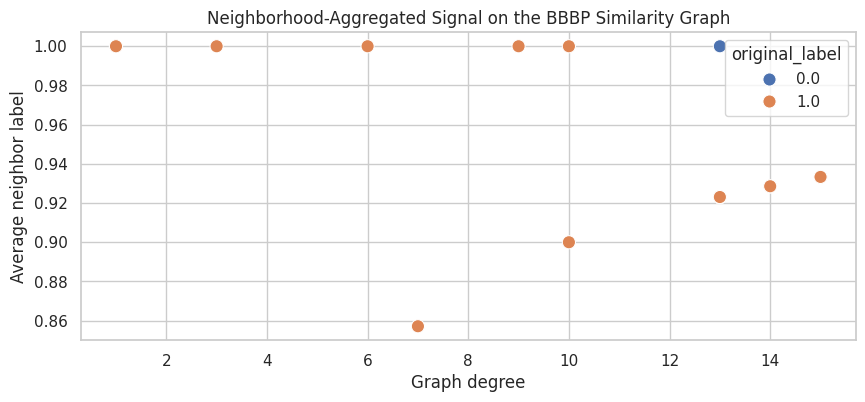

In [111]:
plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=comparison_df, x="degree", y="neighbor_average", hue="original_label", s=90
)
plt.title("Neighborhood-Aggregated Signal on the BBBP Similarity Graph")
plt.xlabel("Graph degree")
plt.ylabel("Average neighbor label")
plt.show()